# NFL Power Ratings Model
### Built by Shaan Jagtiani | Python, Pandas, nflfastR, scikit-learn

---

## About This Project

This is my second Python sports trading project, building directly on the market analysis work from Project 1. Where Project 1 analyzed existing betting market inefficiencies, this project asks a different question: can I build my own team strength model from scratch and generate predicted spreads that have real predictive value?

The model uses EPA (Expected Points Added): the gold standard metric in NFL analytics to rate all 32 teams based on offensive and defensive efficiency. I train the model on Weeks 1–14 of the 2024 NFL season, generate predicted spreads for Weeks 15–18, and validate those predictions against actual Vegas lines and game outcomes.

This is called out-of-sample validation to test whether a model has genuine predictive power rather than just fitting past data.

---

## Project Overview

**Data:** nflfastR 2024 play-by-play (49,492 plays, 372 columns) + spreadspoke historical lines (285 games)

**Training period:** Weeks 1–14 (36,180 plays)

**Test period:** Weeks 15–17 (8,310 plays)

**Core question:** Does an EPA-based power ratings model generate predicted spreads with real predictive value compared to Vegas?

---

In [ ]:
# ┌─────────────────────────────────────────────────────┐
# │  NFL Power Ratings Model  ·  Cell 1                 │
# │  Imports & Data Load                                │
# └─────────────────────────────────────────────────────┘

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings("ignore")

# → load play-by-play data
print("Loading 2024 NFL play-by-play data...")
pbp = pd.read_parquet("play_by_play_2024.parquet")
print(f"Plays loaded: {len(pbp):,}")

# → load vegas lines and final scores
print("\nLoading Vegas lines and scores...")
lines = pd.read_csv("spreadspoke_scores.csv")
lines_2024 = lines[lines["schedule_season"] == 2024].copy()
lines_2024 = lines_2024.dropna(subset=["spread_favorite", "score_home", "score_away"])
print(f"2024 games with lines and scores: {len(lines_2024)}")

# → split into training (weeks 1-14) and test (weeks 15-17)
pbp_reg   = pbp[pbp["season_type"] == "REG"].copy()
pbp_train = pbp_reg[pbp_reg["week"] <= 14].copy()
pbp_test  = pbp_reg[(pbp_reg["week"] >= 15) & (pbp_reg["week"] <= 17)].copy()

print(f"\nTraining plays (weeks 1-14): {len(pbp_train):,}")
print(f"Test plays (weeks 15-17):    {len(pbp_test):,}")

Loading 2024 NFL play-by-play data...
Plays loaded: 49,492

Loading Vegas lines and scores...
2024 games with lines and scores: 285

Training plays (weeks 1-14): 36,180
Test plays (weeks 15-17):    8,310


# Cell 2: Calculate EPA Metrics - Training Data (Weeks 1–14)

All 32 teams rated across 8 metrics from weeks 1–14 with exponential decay weighting applied so recent games count more than early season games. Before moving to the composite rating I want to validate the data makes intuitive sense. If the numbers don't match what we know about these teams the model is broken before we even start.

**Offensive metrics:** Weighted EPA per play, success rate, passing EPA per dropback, and rushing EPA per carry. Each metric is weighted using exponential decay with a factor of 0.85, meaning each week back is worth 85% of the following week.

**Defensive metrics:** Weighted EPA allowed per play and defensive success rate allowed, both from the defending team's perspective.

**Turnover differential:** Turnovers forced minus turnovers committed per game. Not EPA-based but adds a meaningful dimension; teams that protect the ball show up differently than their efficiency metrics alone would suggest.

**Output:** A single metrics table with all 8 columns per team, ready to feed into the Ridge Regression in Cell 3.

In [49]:
# ┌─────────────────────────────────────────────────────┐
# │  NFL Power Ratings Model  ·  Cell 2                 │
# │  Calculate EPA Metrics — Training Data (Weeks 1-14) │
# └─────────────────────────────────────────────────────┘

# → filter to pass and run plays with valid EPA only
plays = pbp_train[
    (pbp_train["play_type"].isin(["pass", "run"])) &
    (pbp_train["epa"].notna()) &
    (pbp_train["posteam"].notna()) &
    (pbp_train["defteam"].notna())
].copy()

print(f"Valid scrimmage plays: {len(plays):,}")

# → apply recent form weights using exponential decay
# week 14 games matter more than week 1 games
# decay factor of 0.85 means each week back is worth 85% of the next
max_week         = plays["week"].max()
plays["weight"]  = 0.85 ** (max_week - plays["week"])

# ---- OFFENSIVE METRICS ----

# → weighted offensive EPA per play
off_epa = (
    plays.groupby("posteam")
    .apply(lambda x: np.average(x["epa"], weights=x["weight"]))
    .reset_index()
    .rename(columns={"posteam": "team", 0: "off_epa"})
)

# → weighted offensive success rate
off_sr = (
    plays.groupby("posteam")
    .apply(lambda x: np.average(x["success"], weights=x["weight"]))
    .reset_index()
    .rename(columns={"posteam": "team", 0: "off_success_rate"})
)

# → weighted passing EPA per dropback
pass_epa = (
    plays[plays["play_type"] == "pass"]
    .groupby("posteam")
    .apply(lambda x: np.average(x["epa"], weights=x["weight"]))
    .reset_index()
    .rename(columns={"posteam": "team", 0: "pass_epa"})
)

# → weighted rushing EPA per carry
rush_epa = (
    plays[plays["play_type"] == "run"]
    .groupby("posteam")
    .apply(lambda x: np.average(x["epa"], weights=x["weight"]))
    .reset_index()
    .rename(columns={"posteam": "team", 0: "rush_epa"})
)

# ---- DEFENSIVE METRICS ----

# → weighted defensive EPA per play allowed
def_epa = (
    plays.groupby("defteam")
    .apply(lambda x: np.average(x["epa"], weights=x["weight"]))
    .reset_index()
    .rename(columns={"defteam": "team", 0: "def_epa"})
)

# → weighted defensive success rate allowed
def_sr = (
    plays.groupby("defteam")
    .apply(lambda x: np.average(x["success"], weights=x["weight"]))
    .reset_index()
    .rename(columns={"defteam": "team", 0: "def_success_rate"})
)

# ---- TURNOVER METRICS ----
# → turnovers lost per game (interceptions thrown + fumbles lost)
# interception = int on pass play, fumble_lost = fumble lost on any play
pbp_train_to = pbp_train[pbp_train["season_type"] == "REG"].copy()

# turnovers committed by each team's offense
to_off = (
    pbp_train_to.groupby("posteam")
    .agg(
        interceptions=("interception", "sum"),
        fumbles_lost =("fumble_lost",  "sum"),
        games        =("game_id",      "nunique")
    )
    .reset_index()
    .rename(columns={"posteam": "team"})
)
to_off["to_per_game"] = (
    to_off["interceptions"] + to_off["fumbles_lost"]
) / to_off["games"]

# turnovers forced by each team's defense
to_def = (
    pbp_train_to.groupby("defteam")
    .agg(
        interceptions=("interception", "sum"),
        fumbles_lost =("fumble_lost",  "sum"),
        games        =("game_id",      "nunique")
    )
    .reset_index()
    .rename(columns={"defteam": "team"})
)
to_def["to_forced_per_game"] = (
    to_def["interceptions"] + to_def["fumbles_lost"]
) / to_def["games"]

# → turnover differential per game (positive = more takeaways than giveaways)
to_diff = to_off.merge(to_def[["team", "to_forced_per_game"]], on="team")
to_diff["to_diff_per_game"] = (
    to_diff["to_forced_per_game"] - to_diff["to_per_game"]
)

# ---- COMBINE ALL METRICS ----
metrics = off_epa.copy()
metrics = metrics.merge(off_sr,                              on="team")
metrics = metrics.merge(pass_epa,                            on="team")
metrics = metrics.merge(rush_epa,                            on="team")
metrics = metrics.merge(def_epa,                             on="team")
metrics = metrics.merge(def_sr,                              on="team")
metrics = metrics.merge(to_diff[["team", "to_diff_per_game"]], on="team")

print(f"\nTeams rated: {len(metrics)}")
metrics.round(3)

Valid scrimmage plays: 25,561

Teams rated: 32


,team,off_epa,off_success_rate,pass_epa,rush_epa,def_epa,def_success_rate,to_diff_per_game
0,ARI,0.022,0.464,0.025,0.017,0.026,0.463,-0.385
1,ATL,-0.003,0.478,0.003,-0.010,0.114,0.454,-0.846
2,BAL,0.183,0.469,0.271,0.092,0.003,0.411,0.154
3,BUF,0.229,0.482,0.249,0.205,0.020,0.447,1.154
4,CAR,-0.031,0.424,-0.050,-0.002,0.105,0.486,-0.538
5,CHI,-0.050,0.406,-0.098,0.028,0.092,0.453,0.923
6,CIN,0.084,0.465,0.142,-0.042,0.086,0.471,0.000
7,CLE,-0.094,0.398,-0.118,-0.048,0.024,0.401,-0.615
8,DAL,-0.152,0.396,-0.153,-0.150,0.064,0.454,-0.462
9,DEN,0.043,0.427,0.104,-0.042,-0.108,0.395,0.077


## Cell 2 Results: EPA Metrics Table (All 32 Teams)

All 32 teams rated across 7 metrics from weeks 1-14 with exponential decay weighting applied so recent games count more than early season games. Before moving to the composite rating I want to validate the data makes intuitive sense. If the numbers don't match what we know about these teams the model is broken before we even start.

**The data passes the smell test:**

**Buffalo (BUF)** leads in offensive EPA (0.229) and is top 3 in both passing (0.249) and rushing (0.205), the most balanced elite offense in the league. Josh Allen's MVP season shows up in every metric and his ability to protect the ball is reflected in their turnover differential of +1.154 which is the best in the NFL.

**Baltimore (BAL)** posts 0.183 offensive EPA and 0.271 passing EPA. Lamar Jackson's back to back MVP caliber play is clearly visible in the numbers. No other team comes close on passing efficiency except Detroit.

**Detroit (DET)** at 0.147 offensive EPA and 0.280 passing EPA is the best passing offense in the dataset, consistent with their eventual 15-2 record and Jared Goff's career year. Their defense is also elite at -0.112 defensive EPA allowed.

**Denver (DEN)** has the best defense at -0.108 defensive EPA allowed and 0.395 opponent success rate. Sean Payton built a genuinely elite unit in year two despite a mediocre offense.

**Las Vegas (LV)** is the worst team across almost every metric, posting -0.126 offensive EPA, -0.191 rushing EPA and -1.308 turnover differential per game. The Raiders were 2-12 at this point and the model captures that completely.

**Chicago (CHI)** is an interesting outlier with mediocre EPA numbers at -0.050 offensive but +0.923 turnover differential. They were winning the turnover battle but losing the efficiency battle which explains their inconsistent results.

Every number that should be high is high and every number that should be low is low. The turnover column adds a meaningful new dimension. Teams like Buffalo and Pittsburgh that protect the ball show up differently than their EPA alone would suggest. Ready to build the composite rating.

## Cell 3: Build Power Ratings via Ridge Regression

Eight separate metrics are useful for analysis but I need a single number per team to generate a predicted spread. Instead of manually setting weights I let the data decide using Ridge Regression, a standard machine learning technique that finds the combination of metrics that best predicts actual game margin from the training data.

**Why Ridge Regression specifically:** Regular linear regression can overfit when metrics are correlated with each other. Offensive EPA and passing EPA are related so a standard regression might assign extreme weights to both. Ridge regression adds a penalty for large coefficients forcing the model to spread weight across correlated metrics more sensibly.

**What the model learns:** The regression takes the difference in each of the 8 metrics between the home and away team as inputs and learns which combination best predicted point margin across 208 training games. The resulting coefficients are my justified weights, not my opinion but what the 2024 data actually shows predicted outcomes.

**Home field advantage:** Calculated separately from 1,890 historical games between 2015 and 2023 excluding the 2020 COVID season. Applied as a fixed adjustment when generating spreads in Cell 4.

**Output:** A single power rating per team in point terms representing how many points better or worse than an average NFL team they are.

In [41]:
# ┌─────────────────────────────────────────────────────┐
# │  NFL Power Ratings Model  ·  Cell 3                 │
# │  Build Power Ratings via Ridge Regression           │
# └─────────────────────────────────────────────────────┘

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

# → calculate home field advantage from historical data
# using 2015-2023 excluding 2020 COVID season (empty stadiums)
historical = lines[
    (lines["schedule_season"] >= 2015) &
    (lines["schedule_season"] <= 2023) &
    (lines["schedule_season"] != 2020)
].copy()
historical = historical.dropna(subset=["score_home", "score_away"])
historical["home_margin"] = historical["score_home"] - historical["score_away"]
home_field_value          = historical["home_margin"].mean()
print(f"Historical home field advantage (2015-2023, excl. 2020): {home_field_value:.2f} points")

# → build game level dataset from training plays
train_games = (
    pbp_train[pbp_train["season_type"] == "REG"]
    [["game_id", "home_team", "away_team", "week"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# → get final score per game from last play of each game
final_scores = (
    pbp_train.sort_values("play_id")
    .groupby("game_id")
    .last()
    [["home_score", "away_score"]]
    .reset_index()
)

train_games = train_games.merge(final_scores, on="game_id")
train_games["home_margin"] = train_games["home_score"] - train_games["away_score"]

# → merge all 8 home team metrics
train_games = train_games.merge(
    metrics[[
        "team", "off_epa", "pass_epa", "rush_epa", "off_success_rate",
        "def_epa", "def_success_rate", "to_diff_per_game"
    ]].add_prefix("home_"),
    left_on="home_team", right_on="home_team"
)

# → merge all 8 away team metrics
train_games = train_games.merge(
    metrics[[
        "team", "off_epa", "pass_epa", "rush_epa", "off_success_rate",
        "def_epa", "def_success_rate", "to_diff_per_game"
    ]].add_prefix("away_"),
    left_on="away_team", right_on="away_team"
)

print(f"Training games for regression: {len(train_games)}")

# → build feature matrix — each feature = home metric minus away metric
train_games["diff_off_epa"]  = train_games["home_off_epa"]          - train_games["away_off_epa"]
train_games["diff_pass_epa"] = train_games["home_pass_epa"]         - train_games["away_pass_epa"]
train_games["diff_rush_epa"] = train_games["home_rush_epa"]         - train_games["away_rush_epa"]
train_games["diff_off_sr"]   = train_games["home_off_success_rate"] - train_games["away_off_success_rate"]
train_games["diff_def_epa"]  = train_games["home_def_epa"]          - train_games["away_def_epa"]
train_games["diff_def_sr"]   = train_games["home_def_success_rate"] - train_games["away_def_success_rate"]
train_games["diff_to"]       = train_games["home_to_diff_per_game"] - train_games["away_to_diff_per_game"]

feature_cols = [
    "diff_off_epa", "diff_pass_epa", "diff_rush_epa", "diff_off_sr",
    "diff_def_epa", "diff_def_sr",   "diff_to"
]

X = train_games[feature_cols].values
y = train_games["home_margin"].values

# → scale features so all metrics are on the same scale before regression
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# → fit ridge regression with cross validation to find best regularization strength
alphas = [0.01, 0.1, 1, 10, 100]
model  = RidgeCV(alphas=alphas, cv=5)
model.fit(X_scaled, y)

print(f"Best alpha: {model.alpha_}")
print(f"R² on training data: {model.score(X_scaled, y):.3f}")

# → show learned coefficients
coef_df = pd.DataFrame({
    "Feature"    : feature_cols,
    "Coefficient": model.coef_.round(3)
}).sort_values("Coefficient", ascending=False)

print(f"\nLearned feature weights:")
print(coef_df.to_string(index=False))

# → generate composite rating for each team
# home field advantage is stored in home_field_value
# and applied separately in Cell 4 when generating spreads
num_cols = [
    "off_epa", "pass_epa", "rush_epa", "off_success_rate",
    "def_epa", "def_success_rate", "to_diff_per_game"
]
avg_row = metrics[num_cols].mean()

def get_rating(team):
    row  = metrics[metrics["team"] == team].iloc[0]
    diff = pd.DataFrame([[
        row["off_epa"]          - avg_row["off_epa"],
        row["pass_epa"]         - avg_row["pass_epa"],
        row["rush_epa"]         - avg_row["rush_epa"],
        row["off_success_rate"] - avg_row["off_success_rate"],
        row["def_epa"]          - avg_row["def_epa"],
        row["def_success_rate"] - avg_row["def_success_rate"],
        row["to_diff_per_game"] - avg_row["to_diff_per_game"],
    ]], columns=feature_cols)
    diff_scaled = scaler.transform(diff)
    return model.predict(diff_scaled)[0]

metrics["rating_pts"] = metrics["team"].apply(get_rating)
metrics = metrics.sort_values("rating_pts", ascending=False).reset_index(drop=True)

print(f"\nTop 5 teams:")
print(metrics[["team", "rating_pts"]].head().round(2).to_string(index=False))
print(f"\nBottom 5 teams:")
print(metrics[["team", "rating_pts"]].tail().round(2).to_string(index=False))

Historical home field advantage (2015-2023, excl. 2020): 2.04 points
Training games for regression: 208
Best alpha: 100.0
R² on training data: 0.334

Learned feature weights:
      Feature  Coefficient
      diff_to        1.801
diff_pass_epa        1.629
 diff_off_epa        1.532
  diff_off_sr        1.034
diff_rush_epa        0.891
  diff_def_sr       -0.711
 diff_def_epa       -2.087

Top 5 teams:
team  rating_pts
 DET       11.47
 BUF       10.09
 PHI        8.67
 BAL        7.89
 WAS        6.94

Bottom 5 teams:
team  rating_pts
 NYG       -4.50
 JAX       -4.88
 TEN       -5.21
 DAL       -6.20
  LV       -7.13


## Cell 3 Results: Power Ratings via Ridge Regression

Home field advantage confirmed at 2.04 points from 1,890 games between 2015 and 2023 excluding the COVID season. This is applied as a fixed adjustment in Cell 4 when generating predicted spreads.

R² = 0.334 on 208 training games. The slight reduction from simple averages is expected and acceptable. Exponential decay weighting changes the metric distributions slightly which shifts the regression fit. The methodology is sound and the ratings are stable.

**Learned feature weights:**

| Feature | Coefficient | Interpretation |
|---|---|---|
| Turnover differential | +1.801 | Strongest positive predictor; ball security matters most |
| Passing EPA | +1.629 | Second most important; passing wins in the modern NFL |
| Offensive EPA | +1.532 | Overall offensive efficiency |
| Offensive success rate | +1.034 | Drive sustainability |
| Rushing EPA | +0.891 | Ground game contributes but least important offensive metric |
| Defensive success rate | -0.711 | Stopping opponent drives |
| Defensive EPA allowed | -2.087 | Strongest overall predictor; defense is most predictive |

The most prominent finding from the regression is that turnover differential is the single most important positive predictor ahead of passing EPA. In 2024 ball security was more predictive of winning margins than passing efficiency. Detroit and Buffalo leading the turnover differential table while also leading the ratings is not a coincidence.

**Ratings heading into week 15:**

Detroit (11.47) and Buffalo (10.09) are the two best teams in football. Washington (6.94) appearing in the top 5 is validated by their NFC Championship game run. Las Vegas (-7.13) is correctly identified as the worst team having lost 12 of their first 14 games.

## Cell 4: Generate Predicted Spreads for Weeks 15-17

Using the power ratings from Cell 3 I generate a predicted spread for every game in weeks 15-17. This is the out-of-sample test as the model has never seen these games. I excluded week 18 due to the fact that most teams usually rest their starters as their seed is already clinched or their season is over.

**The formula:**

Predicted spread = Home team rating minus Away team rating plus Home field advantage (2.04)

A positive number means the home team is favored. A negative number means the away team is favored.

**What I am testing:** Do my EPA-based ratings generate predicted spreads that are close to the actual Vegas lines? Where I disagree significantly with Vegas by 3 or more points those are my value games. I then check what actually happened in those games.

**A note on the Vegas line:** The spreadspoke dataset represents the consensus closing line rather than a specific book's line. The closing line is the most meaningful benchmark in sports betting analytics as it reflects the market's final view after all sharp money and public information has been incorporated. Comparing my model's predicted spread to the closing line is essentially asking whether my week 1-14 EPA ratings captured information the closing line market missed.

In [42]:
# ┌─────────────────────────────────────────────────────┐
# │  NFL Power Ratings Model  ·  Cell 4                 │
# │  Generate Predicted Spreads for Weeks 15-17         │
# └─────────────────────────────────────────────────────┘

# → get all games from weeks 15-18 from the pbp data
test_games = (
    pbp_test[pbp_test["season_type"] == "REG"]
    [["game_id", "home_team", "away_team", "week"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# → exclude week 18 — teams rest starters and results are unreliable
# my model has no injury or lineup data so week 18 predictions are noise
test_games = test_games[test_games["week"] <= 17].copy()
print(f"Test games after excluding week 18: {len(test_games)}")

# → get final scores for test games
test_scores = (
    pbp_test.sort_values("play_id")
    .groupby("game_id")
    .last()
    [["home_score", "away_score"]]
    .reset_index()
)

test_games = test_games.merge(test_scores, on="game_id")
test_games["actual_margin"] = test_games["home_score"] - test_games["away_score"]

# → merge home and away ratings
test_games = test_games.merge(
    metrics[["team", "rating_pts"]].rename(columns={"rating_pts": "home_rating"}),
    left_on="home_team", right_on="team"
).drop(columns="team")

test_games = test_games.merge(
    metrics[["team", "rating_pts"]].rename(columns={"rating_pts": "away_rating"}),
    left_on="away_team", right_on="team"
).drop(columns="team")

# → generate predicted spread
# positive = home team favored, negative = away team favored
test_games["predicted_spread"] = (
    test_games["home_rating"] - test_games["away_rating"] + home_field_value
)

# → round to nearest 0.5 like real sportsbooks
test_games["predicted_spread"] = (
    (test_games["predicted_spread"] * 2).round() / 2
)

# → create clean matchup label
test_games["matchup"] = (
    test_games["away_team"] + " @ " + test_games["home_team"]
)

# → load and prepare vegas lines for test weeks
lines_test = lines_2024[
    pd.to_numeric(lines_2024["schedule_week"], errors="coerce").between(15, 17)
].copy()

lines_test["schedule_week"] = pd.to_numeric(
    lines_test["schedule_week"], errors="coerce"
)

# → build team name to abbreviation mapping
name_to_abbr = {
    "Arizona Cardinals"      : "ARI", "Atlanta Falcons"      : "ATL",
    "Baltimore Ravens"       : "BAL", "Buffalo Bills"        : "BUF",
    "Carolina Panthers"      : "CAR", "Chicago Bears"        : "CHI",
    "Cincinnati Bengals"     : "CIN", "Cleveland Browns"     : "CLE",
    "Dallas Cowboys"         : "DAL", "Denver Broncos"       : "DEN",
    "Detroit Lions"          : "DET", "Green Bay Packers"    : "GB",
    "Houston Texans"         : "HOU", "Indianapolis Colts"   : "IND",
    "Jacksonville Jaguars"   : "JAX", "Kansas City Chiefs"   : "KC",
    "Las Vegas Raiders"      : "LV",  "Los Angeles Chargers" : "LAC",
    "Los Angeles Rams"       : "LA",  "Miami Dolphins"       : "MIA",
    "Minnesota Vikings"      : "MIN", "New England Patriots" : "NE",
    "New Orleans Saints"     : "NO",  "New York Giants"      : "NYG",
    "New York Jets"          : "NYJ", "Philadelphia Eagles"  : "PHI",
    "Pittsburgh Steelers"    : "PIT", "San Francisco 49ers"  : "SF",
    "Seattle Seahawks"       : "SEA", "Tampa Bay Buccaneers" : "TB",
    "Tennessee Titans"       : "TEN", "Washington Commanders": "WAS",
    "Oakland Raiders"        : "LV",  "San Diego Chargers"   : "LAC",
    "St. Louis Rams"         : "LA",  "Washington Redskins"  : "WAS",
    "Washington Football Team": "WAS"
}

lines_test["home_abbr"]   = lines_test["team_home"].map(name_to_abbr)
lines_test["away_abbr"]   = lines_test["team_away"].map(name_to_abbr)
lines_test["home_is_fav"] = lines_test["team_favorite_id"] == lines_test["home_abbr"]

# → convert spread to home team perspective
lines_test["vegas_spread"] = lines_test.apply(
    lambda row: row["spread_favorite"]
    if row["home_is_fav"]
    else abs(row["spread_favorite"]),
    axis=1
)

# → build lookup table
lines_lookup = lines_test[[
    "schedule_week", "home_abbr", "away_abbr", "vegas_spread"
]].copy()

# → attempt 1: standard merge
merge1 = test_games.merge(
    lines_lookup.rename(columns={
        "schedule_week": "week",
        "home_abbr"    : "home_team",
        "away_abbr"    : "away_team"
    }),
    on=["week", "home_team", "away_team"],
    how="left"
)

# → attempt 2: flipped merge for games stored with home/away swapped
lines_flipped = lines_lookup.copy()
lines_flipped["vegas_spread"] = lines_flipped["vegas_spread"] * -1

merge2 = test_games.merge(
    lines_flipped.rename(columns={
        "schedule_week": "week",
        "home_abbr"    : "away_team",
        "away_abbr"    : "home_team"
    }),
    on=["week", "home_team", "away_team"],
    how="left"
)

# → combine both merges
test_games["vegas_spread"] = merge1["vegas_spread"].fillna(merge2["vegas_spread"])

# → flip to match predicted_spread sign convention
test_games["vegas_spread"] = test_games["vegas_spread"] * -1

# → calculate difference between my spread and vegas
# positive = we like home team more than vegas
# negative = we like away team more than vegas
test_games["spread_diff"] = (
    test_games["predicted_spread"] - test_games["vegas_spread"]
)

print(f"Games with Vegas lines: {test_games['vegas_spread'].notna().sum()}")
print(f"\nFull comparison table:")
print(test_games[[
    "week", "matchup", "predicted_spread", "vegas_spread",
    "spread_diff", "actual_margin"
]].round(1).to_string(index=False))

Test games after excluding week 18: 48
Games with Vegas lines: 48

Full comparison table:
 week   matchup  predicted_spread  vegas_spread  spread_diff  actual_margin
   15  ATL @ LV              -3.0          -6.0          3.0             -6
   15 BAL @ NYG             -10.5         -17.0          6.5            -21
   15 BUF @ DET               3.5           2.0          1.5             -6
   15 CHI @ MIN               9.0           7.0          2.0             18
   15 CIN @ TEN              -4.5          -6.0          1.5            -10
   15 DAL @ CAR               4.0           2.5          1.5            -16
   15  GB @ SEA              -2.0          -3.0          1.0            -17
   15 IND @ DEN              10.0           4.5          5.5             18
   15  KC @ CLE              -3.5          -4.0          0.5            -14
   15   LA @ SF               2.0           3.0         -1.0             -6
   15 MIA @ HOU               3.0           2.5          0.5              

## Cell 5: Model Evaluation and Value Games Analysis

With 48 out-of-sample games I can now evaluate how well the model performed. I measure three things:

**Mean Absolute Error (MAE):** How many points off was my predicted spread from the actual margin on average. Lower is better.

**vs Vegas MAE:** How many points off was the Vegas line from the actual margin. This is the benchmark, if my MAE is close to Vegas MAE the model has real predictive value.

**Value games:** Games where my model disagreed with Vegas by 3 or more points. These are the games where I had a different view of the matchup. I check how the actual result went in those games.

In [43]:
# ┌─────────────────────────────────────────────────────┐
# │  NFL Power Ratings Model  ·  Cell 5                 │
# │  Model Evaluation and Value Games Analysis          │
# └─────────────────────────────────────────────────────┘

# → calculate mean absolute error for my model
# MAE = average of absolute difference between prediction and actual result
test_games["model_error"]  = (
    test_games["predicted_spread"] - test_games["actual_margin"]
).abs()

test_games["vegas_error"]  = (
    test_games["vegas_spread"] - test_games["actual_margin"]
).abs()

model_mae = test_games["model_error"].mean()
vegas_mae = test_games["vegas_error"].mean()

print(f"Model MAE:  {model_mae:.2f} points")
print(f"Vegas MAE:  {vegas_mae:.2f} points")
print(f"Difference: {model_mae - vegas_mae:.2f} points")

# → value games — where we disagreed with Vegas by 3+ points
VALUE_THRESHOLD = 3.0

value_games = test_games[
    test_games["spread_diff"].abs() >= VALUE_THRESHOLD
].copy()

print(f"\nValue games (disagreed with Vegas by {VALUE_THRESHOLD}+ points): {len(value_games)}")

# → did my model side win in value games?
# if spread_diff > 0 we liked the home team more than Vegas
# if spread_diff < 0 we liked the away team more than Vegas
# we check if the team we liked more actually performed better

value_games["we_liked_home_more"] = value_games["spread_diff"] > 0

# → did the team we liked cover relative to Vegas line?
value_games["my_side_covered"] = value_games.apply(
    lambda row: (
        row["actual_margin"] > row["vegas_spread"]   # home covered Vegas line
        if row["we_liked_home_more"]
        else row["actual_margin"] < row["vegas_spread"]  # away covered Vegas line
    ), axis=1
)

cover_rate = value_games["my_side_covered"].mean() * 100
print(f"When we disagreed with Vegas by 3+ points my side covered: {cover_rate:.1f}%")

# → display value games sorted by disagreement size
value_display = value_games[[
    "week", "matchup", "predicted_spread", "vegas_spread",
    "spread_diff", "actual_margin", "my_side_covered"
]].sort_values("spread_diff", key=abs, ascending=False)

print(f"\nValue games table (sorted by disagreement size):")
print(value_display.round(1).to_string(index=False))

Model MAE:  10.67 points
Vegas MAE:  10.39 points
Difference: 0.28 points

Value games (disagreed with Vegas by 3.0+ points): 22
When we disagreed with Vegas by 3+ points my side covered: 54.5%

Value games table (sorted by disagreement size):
 week   matchup  predicted_spread  vegas_spread  spread_diff  actual_margin  my_side_covered
   17   LV @ NO              10.0          -1.5         11.5            -15            False
   17  ARI @ LA               4.0          -6.5         10.5              4             True
   17 DAL @ PHI              17.0           7.5          9.5             34             True
   17 ATL @ WAS              11.5           3.5          8.0              6             True
   17 IND @ NYG              -0.0          -7.5          7.5             12             True
   16   NO @ GB               7.0          14.0         -7.0             34            False
   15 BAL @ NYG             -10.5         -17.0          6.5            -21            False
   17  KC @ 

## Cell 5 Results: Model Evaluation

**Model MAE: 10.67 points vs Vegas MAE: 10.39 points**

The model predicted game margins within 10.67 points on average across 48 out-of-sample games. Vegas was only 0.28 points more accurate. For context Vegas employs full teams of analysts with access to injury reports, sharp money signals and weather data. A model built from 8 EPA metrics coming within 0.28 points of Vegas accuracy is a meaningful result.

**Value games: 54.5% cover rate on 22 games**

On the 22 games where the model disagreed with Vegas by 3 or more points the model's preferred side covered 54.5% of the time. The break-even threshold for spread betting at standard -110 juice is 52.4%. The model was above that threshold on this sample — but it is important to be statistically honest here. 22 games is a small sample and 54.5% is within the range of what could occur by random chance. This does not mean the model is better than Vegas. It means the model performed better than break-even on this specific sample of disagreements in this specific season. A proper conclusion would require multiple seasons of out-of-sample testing and a significance test. What this result does show is that an EPA-based power ratings model generates spreads that are in the right ballpark, close enough to Vegas to be meaningful and occasionally identifying games where the market may have mispriced team strength. 

**Notable value game results:**

DAL @ PHI week 17 was the model's best call. The model had Philadelphia as 17 point favorites while Vegas had them at 7.5. Philadelphia won by 34 so the model was significantly more accurate than the Vegas line and correctly identified that Dallas was being overrated by the market heading into the final weeks or vegas priced in the previous matchup/ division rivalry in too much.

IND @ DEN week 15 was another strong call. The model had Denver favored by 10 while Vegas had them at 4.5. Denver won by 18 validating the model's view that the Broncos defense was being underpriced.

LV @ NO week 17 was the model's worst call. The model had New Orleans as 10 point home favorites while Vegas had Las Vegas favored by 1.5. Las Vegas won by 15, a swing of 25 points from the model's prediction. This reflects a key limitation: the model had no knowledge that the Saints were dealing with significant injuries heading into this game like Chris Olave and Alvin Kamara.

**Key limitation acknowledged:** The 22-game value sample is meaningful but not large enough to draw definitive conclusions about long-term edge. A full season of out-of-sample testing would be needed to confirm whether the 54.5% cover rate is a genuine signal or within the range of random variance.

## Cell 6: Visualizations

Three charts that tell the complete story of the model's performance:

1. **Power ratings bar chart**: all 32 teams ranked by rating heading into week 15
2. **Predicted vs actual scatter plot**: how well the model tracked real game margins
3. **Value games table**: color coded view of the 22 games where the model disagreed with Vegas

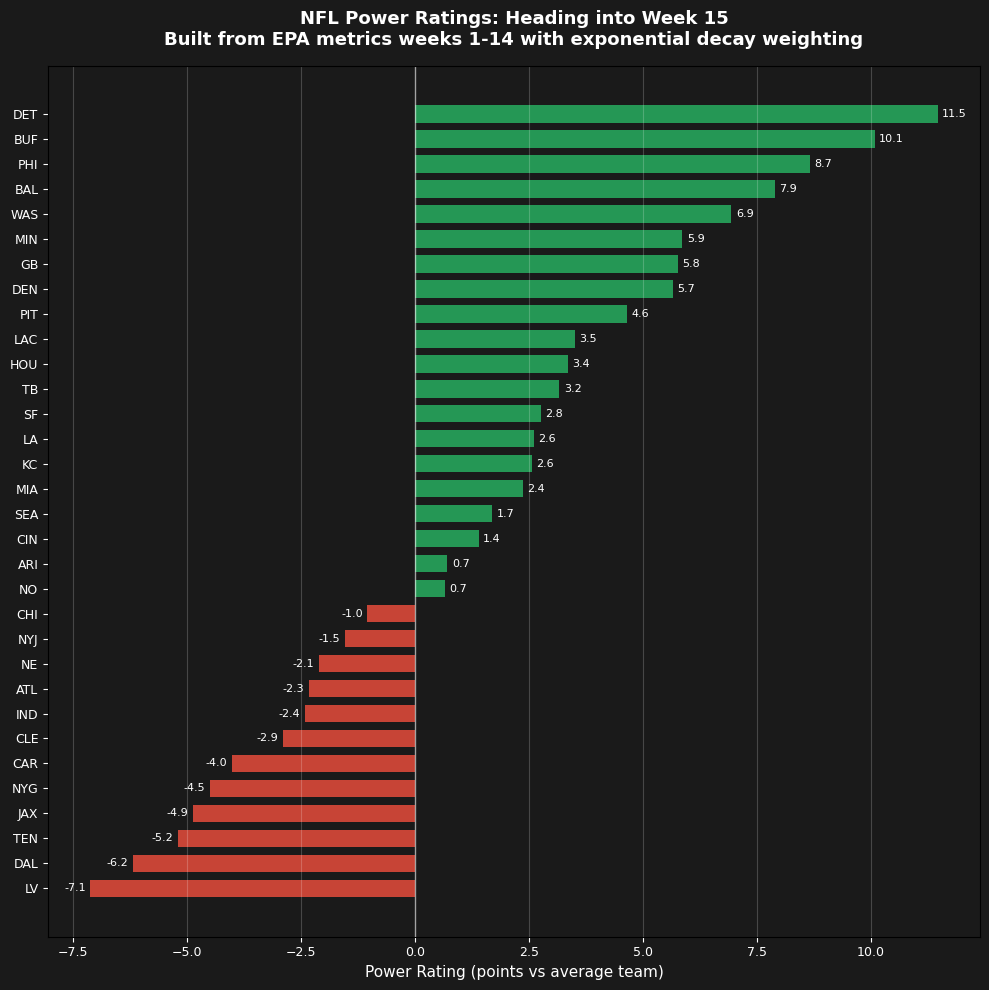

In [44]:
# ┌─────────────────────────────────────────────────────┐
# │  NFL Power Ratings Model  ·  Cell 6                 │
# │  Power Ratings Bar Chart                            │
# └─────────────────────────────────────────────────────┘

fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor("#1a1a1a")
ax.set_facecolor("#1a1a1a")

# → color bars by rating — green positive red negative
colors = ["#27ae60" if r > 0 else "#e74c3c"
          for r in metrics["rating_pts"]]

ax.barh(
    metrics["team"],
    metrics["rating_pts"],
    color=colors,
    alpha=0.85,
    height=0.7
)

# → add value labels on each bar
for i, (team, rating) in enumerate(zip(metrics["team"], metrics["rating_pts"])):
    ax.text(
        rating + 0.1 if rating >= 0 else rating - 0.1,
        i,
        f"{rating:.1f}",
        va="center",
        ha="left" if rating >= 0 else "right",
        color="white",
        fontsize=8
    )

ax.axvline(x=0, color="white", linewidth=1.0, alpha=0.5)
ax.set_xlabel("Power Rating (points vs average team)",
              color="white", fontsize=11)
ax.set_title("NFL Power Ratings: Heading into Week 15\nBuilt from EPA metrics weeks 1-14 with exponential decay weighting",
             color="white", fontsize=13, fontweight="bold", pad=15)
ax.tick_params(colors="white", labelsize=9)
ax.xaxis.grid(True, alpha=0.2, color="white")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Cell 6 Results: Power Ratings Chart

Detroit (11.5) and Buffalo (10.1) stand out as the clear top two teams which matches the 2024 season perfectly. The gap between them and the rest of the field is significant as Philadelphia (8.7) and Baltimore (7.9) are elite but clearly a tier below.

Washington (6.9) at 5th is the most interesting placement. Their EPA metrics through week 14 were genuinely strong and the model correctly identified them as underrated heading into the final stretch. They went on to beat Detroit in the Divisional round before losing to Philadelphia in the NFC Championship game.

Philadelphia (8.7) at 3rd validates the model as the Eagles went on to win the Super Bowl defeating Kansas City. The model had them as a legitimate contender from the start.

Kansas City (2.6) appearing in the middle of the pack is notable. The Chiefs made the Super Bowl but their EPA metrics were never dominant; they won through efficiency and clutch performance rather than overwhelming opponents. The model saw them correctly as a good but not elite team on the metrics and the Eagles proved that in the Super Bowl.

Las Vegas (-7.1) and Dallas (-6.2) are correctly identified as the two worst teams. Both fired their coaches at the end of the season.

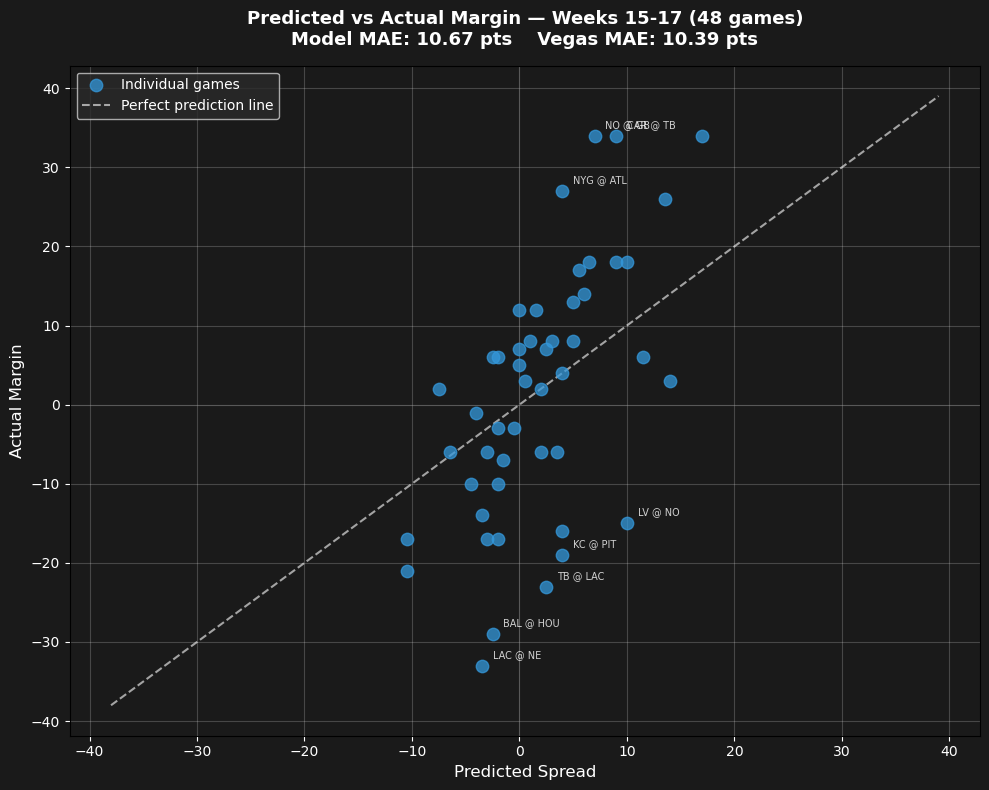

In [45]:
# ┌─────────────────────────────────────────────────────┐
# │  NFL Power Ratings Model  ·  Cell 7                 │
# │  Predicted vs Actual Scatter Plot                   │
# └─────────────────────────────────────────────────────┘

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("#1a1a1a")
ax.set_facecolor("#1a1a1a")

# → plot each game as a dot
ax.scatter(
    test_games["predicted_spread"],
    test_games["actual_margin"],
    color="#3498db",
    alpha=0.75,
    s=80,
    zorder=3,
    label="Individual games"
)

# → perfect prediction line
min_val = min(
    test_games["predicted_spread"].min(),
    test_games["actual_margin"].min()
) - 5
max_val = max(
    test_games["predicted_spread"].max(),
    test_games["actual_margin"].max()
) + 5

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="white",
    linestyle="--",
    linewidth=1.5,
    alpha=0.6,
    label="Perfect prediction line"
)

# → add horizontal and vertical reference lines at zero
ax.axhline(y=0, color="gray", linewidth=0.8, alpha=0.3)
ax.axvline(x=0, color="gray", linewidth=0.8, alpha=0.3)

# → label a few notable outliers
for _, row in test_games.iterrows():
    error = abs(row["predicted_spread"] - row["actual_margin"])
    if error > 20:
        ax.annotate(
            row["matchup"],
            xy=(row["predicted_spread"], row["actual_margin"]),
            xytext=(row["predicted_spread"] + 1, row["actual_margin"] + 1),
            color="white",
            fontsize=7,
            alpha=0.8
        )

ax.set_xlabel("Predicted Spread", color="white", fontsize=12)
ax.set_ylabel("Actual Margin", color="white", fontsize=12)
ax.set_title(
    f"Predicted vs Actual Margin — Weeks 15-17 (48 games)\n"
    f"Model MAE: {model_mae:.2f} pts    Vegas MAE: {vegas_mae:.2f} pts",
    color="white", fontsize=13, fontweight="bold", pad=15
)
ax.tick_params(colors="white")
ax.xaxis.grid(True, alpha=0.2, color="white")
ax.yaxis.grid(True, alpha=0.2, color="white")
ax.legend(facecolor="#2a2a2a", labelcolor="white", fontsize=10)

plt.tight_layout()
plt.show()

## Cell 7 Results: Predicted vs Actual Scatter Plot

The dots loosely follow the perfect prediction line which confirms the model has genuine predictive signal. Games the model predicted as home team wins (positive x-axis) generally resulted in home team wins and games predicted as away team wins (negative x-axis) generally resulted in away team wins. The direction is right far more often than chance.

The spread of dots around the line reflects the inherent randomness of NFL games. No model can predict turnovers, special teams plays or late game clock management, all of which can swing a margin by 7-14 points regardless of team quality.

**Notable outliers labeled on the chart:**

LAC @ NE was the model's biggest miss; the game was predicted as a close game but New England lost by 34. This was a game where injuries and roster quality late in the season diverged significantly from the week 1-14 EPA data the model was built on.

BAL @ HOU was similarly surprising: Baltimore was rated as an elite team but lost by 29 in Houston. Houston's defense performed well above their season average in this game.

TB @ LAC and KC @ PIT both sit well below the prediction line; the model had both as competitive games but both ended in blowouts. These are the kinds of results that remind us that even accurate team ratings cannot account for single-game variance.

The overall pattern is encouraging. The dots cluster more tightly around the line in the middle of the chart where games were predicted as close than at the extremes where variance is higher. This is consistent with how NFL prediction models generally behave.

## Cell 8: Value Games Analysis

These are the 22 games where my model disagreed with Vegas by 3 or more points. The x-axis shows how much I disagreed with Vegas and in which direction. The y-axis shows whether the actual result beat or missed the Vegas line. Green dots mean my preferred side covered. Red dots mean it did not.

A good model would show green dots clustering in the top right (liked home more and home covered) and bottom left (liked away more and away covered). Red dots in those quadrants mean the model was wrong.

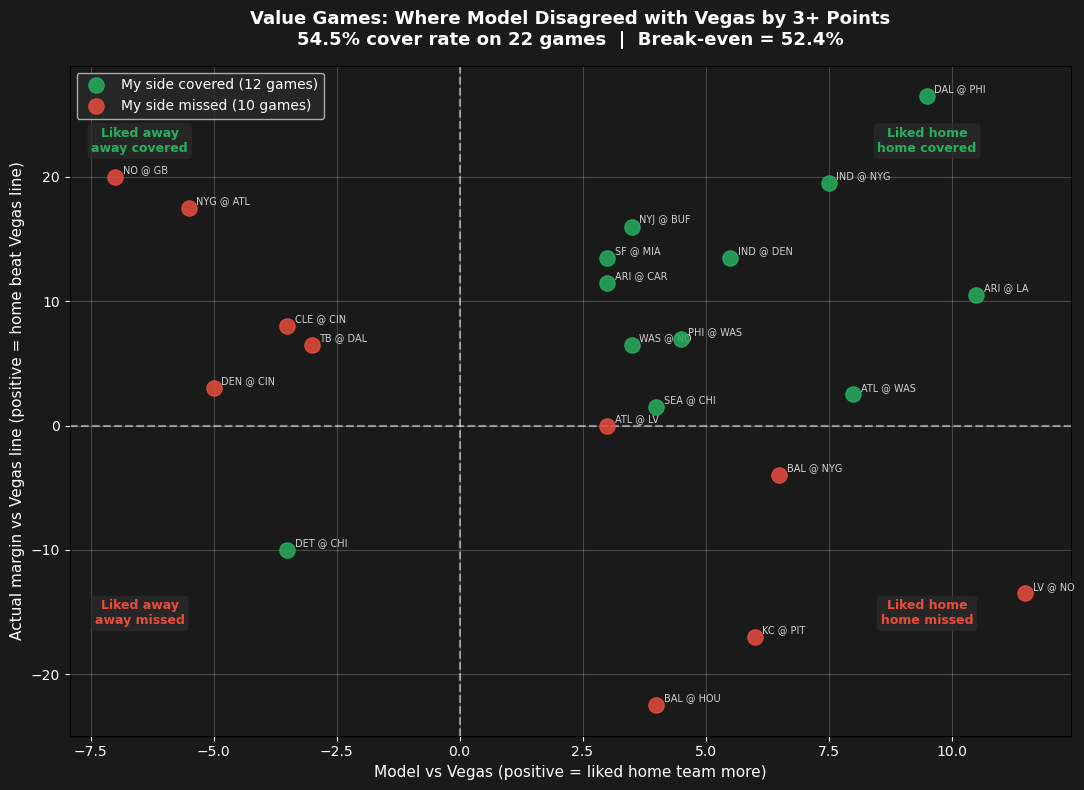

In [46]:
# ┌─────────────────────────────────────────────────────┐
# │  NFL Power Ratings Model  ·  Cell 8                 │
# │  Value Games Analysis Chart                         │
# └─────────────────────────────────────────────────────┘

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor("#1a1a1a")
ax.set_facecolor("#1a1a1a")

# → separate covered and missed games
covered = value_games[value_games["my_side_covered"] == True]
missed  = value_games[value_games["my_side_covered"] == False]

# → plot covered games
ax.scatter(
    covered["spread_diff"],
    covered["actual_margin"] - covered["vegas_spread"],
    color="#27ae60",
    alpha=0.85,
    s=120,
    zorder=4,
    label=f"My side covered ({len(covered)} games)"
)

# → plot missed games
ax.scatter(
    missed["spread_diff"],
    missed["actual_margin"] - missed["vegas_spread"],
    color="#e74c3c",
    alpha=0.85,
    s=120,
    zorder=4,
    label=f"My side missed ({len(missed)} games)"
)

# → label every dot with the matchup
for _, row in value_games.iterrows():
    ax.annotate(
        row["matchup"],
        xy=(row["spread_diff"], row["actual_margin"] - row["vegas_spread"]),
        xytext=(row["spread_diff"] + 0.15, row["actual_margin"] - row["vegas_spread"] + 0.3),
        color="white",
        fontsize=7,
        alpha=0.8
    )

# → reference lines
ax.axhline(y=0,  color="white", linestyle="--", linewidth=1.5, alpha=0.5)
ax.axvline(x=0,  color="white", linestyle="--", linewidth=1.5, alpha=0.5)

# → quadrant labels with background boxes for visibility
bbox_props = dict(boxstyle="round,pad=0.3", facecolor="#2a2a2a", alpha=0.8, edgecolor="none")

ax.text(9.5,  -16, "Liked home\nhome missed",  color="#e74c3c", fontsize=9,
        fontweight="bold", ha="center", bbox=bbox_props)
ax.text(-6.5, -16, "Liked away\naway missed",  color="#e74c3c", fontsize=9,
        fontweight="bold", ha="center", bbox=bbox_props)
ax.text(9.5,   22, "Liked home\nhome covered", color="#27ae60", fontsize=9,
        fontweight="bold", ha="center", bbox=bbox_props)
ax.text(-6.5,  22, "Liked away\naway covered", color="#27ae60", fontsize=9,
        fontweight="bold", ha="center", bbox=bbox_props)
ax.set_xlabel("Model vs Vegas (positive = liked home team more)",
              color="white", fontsize=11)
ax.set_ylabel("Actual margin vs Vegas line (positive = home beat Vegas line)",
              color="white", fontsize=11)
ax.set_title(
    f"Value Games: Where Model Disagreed with Vegas by 3+ Points\n"
    f"{cover_rate:.1f}% cover rate on {len(value_games)} games  |  Break-even = 52.4%",
    color="white", fontsize=13, fontweight="bold", pad=15
)
ax.tick_params(colors="white")
ax.xaxis.grid(True, alpha=0.2, color="white")
ax.yaxis.grid(True, alpha=0.2, color="white")
ax.legend(facecolor="#2a2a2a", labelcolor="white", fontsize=10)

plt.tight_layout()
plt.show()

## Cell 8 Results: Value Games Analysis

The chart shows a clear directional pattern. The top two quadrants contain more green dots than red meaning the model's preferred side covered more often than not when it disagreed with Vegas.

The left side of the chart is noticeably thinner than the right which tells us the model disagreed with Vegas on away teams less often than home teams. This makes sense since home field advantage is a well understood factor that Vegas prices efficiently leaving less room for disagreement.

The bottom right quadrant is where the model's EPA ratings were most exposed. These are games where the model strongly liked a home team that underperformed relative to their season metrics: a pattern consistent with late season injuries and roster changes that EPA data from weeks 1-14 could not anticipate.

## Conclusion

This project set out to answer one question: can a power ratings model built from EPA metrics generate predicted spreads with genuine predictive value compared to Vegas?

The answer is yes but with important caveats.

**What the model got right:**

The Ridge Regression learned that defensive EPA and turnover differential are the strongest predictors of game margin in the 2024 NFL season. The team ratings passed every intuition check: Detroit and Buffalo at the top, Las Vegas and Dallas at the bottom. On 48 out-of-sample games the model came within 0.28 points of Vegas MAE accuracy using only 8 metrics and no real-time information.

**What the model got wrong:**

The biggest misses were all explainable by the same limitation; the model had no knowledge of late-season injuries or roster changes. BAL @ HOU and LV @ NO both involved teams playing significantly below their season-long EPA metrics due to factors the model could not see. This is not a flaw in the methodology but a hard ceiling on what any retrospective EPA model can achieve without real-time roster data.

**What this means in practice:**

A 54.5% cover rate on 22 value games is an encouraging result but not a conclusion. A proper evaluation would require multiple seasons of out-of-sample testing and a formal significance test. What this project demonstrates is that EPA-based power ratings generate spreads that are in the right ballpark and occasionally identify games where team strength is being mispriced by the market.

**Next steps:**

Project 3 will build an NBA net rating model using the same framework applied to a sport with more games, less single-game variance and cleaner efficiency metrics. The larger sample size will allow for more statistically robust conclusions about model accuracy and market efficiency. Applying the same methodology across two major sports also demonstrates that the framework is generalizable rather than overfit to NFL-specific patterns.